In [38]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [39]:
df = pd.read_csv('C:/Users/Dell/Desktop/pythonDS/pythonfordsagain/Retail_Data_cleaning_n_analysis/Retail-Data-Analysis/Cleaned_Retail_Store_sales.csv')

In [40]:
df.shape

(11971, 10)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    11971 non-null  object 
 1   Customer_ID       11971 non-null  object 
 2   Category          11971 non-null  object 
 3   Item              11971 non-null  object 
 4   Price_Per_Unit    11971 non-null  float64
 5   Quantity          11971 non-null  int64  
 6   Total_Spent       11971 non-null  float64
 7   Payment_Method    11971 non-null  object 
 8   Location          11971 non-null  object 
 9   Transaction_Date  11971 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 935.4+ KB


In [52]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors = 'coerce')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    11971 non-null  object        
 1   Customer_ID       11971 non-null  object        
 2   Category          11971 non-null  object        
 3   Item              11971 non-null  object        
 4   Price_Per_Unit    11971 non-null  float64       
 5   Quantity          11971 non-null  int64         
 6   Total_Spent       11971 non-null  float64       
 7   Payment_Method    11971 non-null  object        
 8   Location          11971 non-null  object        
 9   Transaction_Date  11971 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 935.4+ KB


In [42]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Category', 'Item', 'Price_Per_Unit',
       'Quantity', 'Total_Spent', 'Payment_Method', 'Location',
       'Transaction_Date'],
      dtype='object')

In [43]:
df.describe(include = 'all')

,Transaction_ID,Customer_ID,Category,Item,Price_Per_Unit,Quantity,Total_Spent,Payment_Method,Location,Transaction_Date
count,11971,11971,11971,11971,11971.000000,11971.000000,11971.000000,11971,11971,11971
unique,11971,25,8,201,NaN,NaN,NaN,3,2,1114
top,TXN_2407494,CUST_24,Furniture,Unknown_Item,NaN,NaN,NaN,Cash,Online,2022-05-30
freq,1,519,1525,609,NaN,NaN,NaN,4103,6068,26
mean,NaN,NaN,NaN,NaN,23.360872,5.536380,129.652577,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.741889,2.857883,94.750697,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN


In [64]:
# 1. Revenue by Category

category_sales = df.groupby('Category')['Total_Spent'].sum()
print(category_sales)

Category
Beverages                             197047.5
Butchers                              208118.0
Computers and electric accessories    190692.5
Electric household essentials         203813.5
Food                                  194812.0
Furniture                             195310.0
Milk Products                         180112.0
Patisserie                            182165.5
Name: Total_Spent, dtype: float64


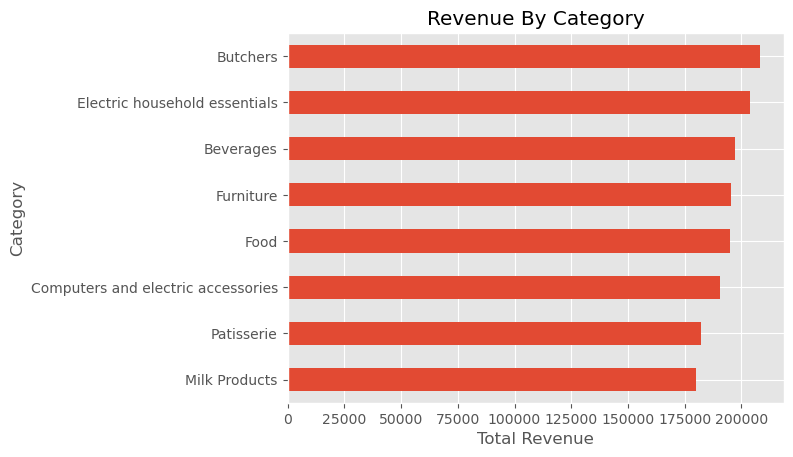

In [66]:
# 1. Revenue by Category chart

category_sales.sort_values().plot(kind = 'barh')

plt.title('Revenue By Category')
plt.xlabel('Total Revenue')
plt.ylabel('Category')

plt.show()

In [46]:
# 2. Payment Method Usage

payment_usage = df['Payment_Method'].value_counts()

print(payment_usage)

Payment_Method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64


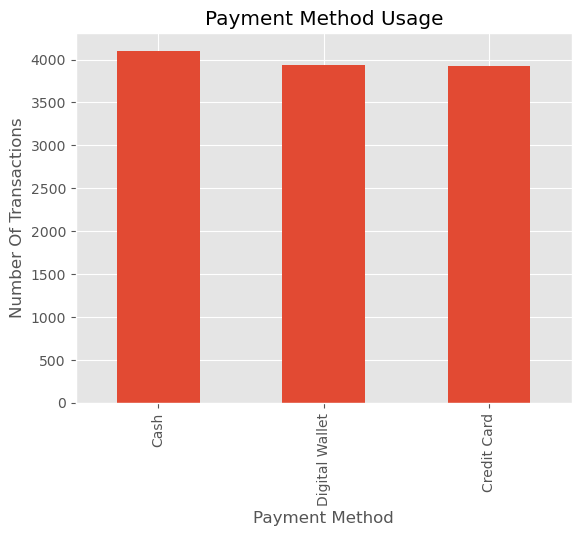

In [47]:
# 2. Payment Method Usage Chart

payment_usage.plot(kind = 'bar')

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number Of Transactions')

plt.show()

In [62]:
# 3. Online vs In-Store Revenue

location_sales = df.groupby('Location')['Total_Spent'].sum()

print(location_sales)

Location
In-store    760670.0
Online      791401.0
Name: Total_Spent, dtype: float64


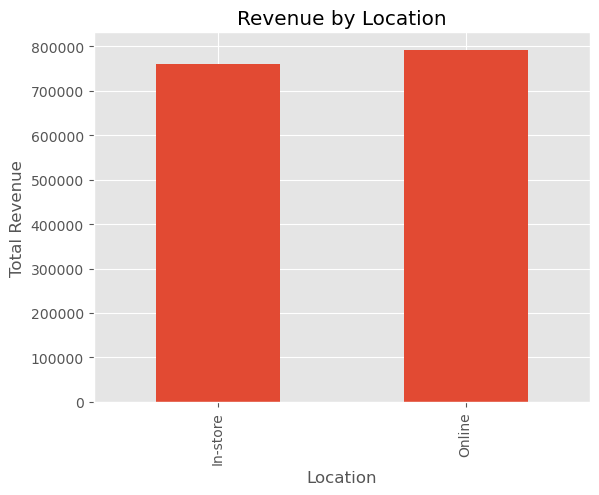

In [63]:
# 3. Online vs In-Store Revenue Chart

location_sales.plot(kind = 'bar')

plt.title('Revenue by Location')
plt.xlabel('Location')
plt.ylabel('Total Revenue')

plt.show()

In [54]:
# 4. Making month column to find the month sales

df['Month'] = df['Transaction_Date'].dt.month

In [60]:
#4. Monthly Sales Trend

monthly_trend = df.groupby('Month')['Total_Spent'].sum()

print(monthly_trend)

Month
1     174421.0
2     119685.0
3     122392.0
4     125618.5
5     124594.5
6     129771.0
7     131509.0
8     123287.5
9     129344.0
10    119413.5
11    122346.5
12    129688.5
Name: Total_Spent, dtype: float64


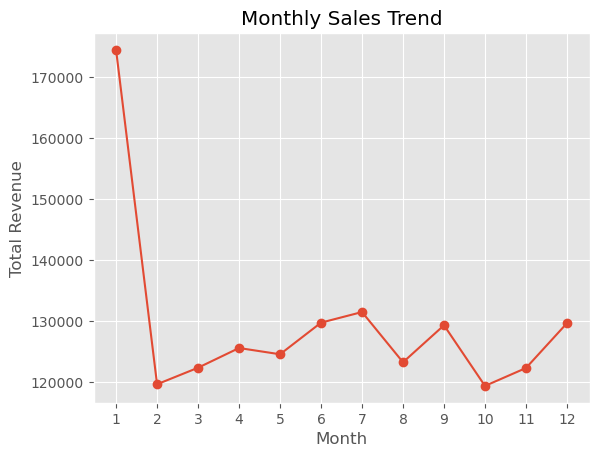

In [67]:
#4. Monthly Sales Trend Chart

monthly_trend.plot(kind = 'line', marker = 'o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.ylabel('Total Revenue')

plt.show()